## Exercise 1.3 — Work to Stretch a Spring

**Problem:** A spring has a natural length of **10 cm**. It takes **2 J** to stretch it to **15 cm**.  
Find the work needed to stretch the spring from **15 cm to 20 cm**.

**Hooke's Law:** The force required to stretch a spring by displacement $x$ from its natural length is:
$$F(x) = kx$$

**Step 1 — Find the spring constant $k$:**

The spring stretches from natural length (10 cm) to 15 cm, so displacement goes from 0 to 5 cm = 0.05 m:
$$W = \int_0^{0.05} kx\, dx = \frac{1}{2}k(0.05)^2 = 2 \text{ J}$$
$$\Rightarrow k = \frac{2 \times 2}{(0.05)^2} = 1600 \text{ N/m}$$

**Step 2 — Compute work from 15 cm to 20 cm:**

Displacement goes from 5 cm to 10 cm (i.e., 0.05 m to 0.10 m):
$$W = \int_{0.05}^{0.10} kx\, dx = \int_{0.05}^{0.10} 1600x\, dx$$

**Analytical Solution:**
$$W = \left[800x^2\right]_{0.05}^{0.10} = 800(0.01) - 800(0.0025) = 8 - 2 = 6 \text{ J}$$

**Answer: $W = 6$ J**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Find the Spring Constant $k$

In [2]:
# Natural length
L0 = 0.10   # 10 cm in meters

# First stretch: natural -> 15 cm, displacement = 5 cm = 0.05 m
x1 = 0.05   # displacement at 15 cm (m)
W1 = 2.0    # work given = 2 J

# W1 = (1/2) * k * x1^2  =>  k = 2*W1 / x1^2
k = (2 * W1) / (x1 ** 2)

print(f'Spring constant k = {k:.2f} N/m')

# Verification
W_check = 0.5 * k * x1**2
print(f'Verification: W = 0.5 * k * x1^2 = {W_check:.2f} J  (should be 2.0 J)')

Spring constant k = 1600.00 N/m
Verification: W = 0.5 * k * x1^2 = 2.00 J  (should be 2.0 J)


## 2. Define the Force Function and Integration Limits

In [3]:
# Force function F(x) = k*x
def F(x):
    """Hooke's Law: F(x) = k*x  [N], x = displacement from natural length [m]"""
    return k * x

# Integration limits: displacement from 5 cm to 10 cm (15 cm -> 20 cm stretch)
a = 0.05   # 5 cm in meters
b = 0.10   # 10 cm in meters
n = 1000   # sub-intervals (even for Simpson's)
h = (b - a) / n
x = np.linspace(a, b, n + 1)
f = F(x)

print(f'Integration limits: x in [{a}, {b}] m  (displacement)')
print(f'Step size         : h = {h:.6f} m')

Integration limits: x in [0.05, 0.1] m  (displacement)
Step size         : h = 0.000050 m


## 3. Plot the Force Function

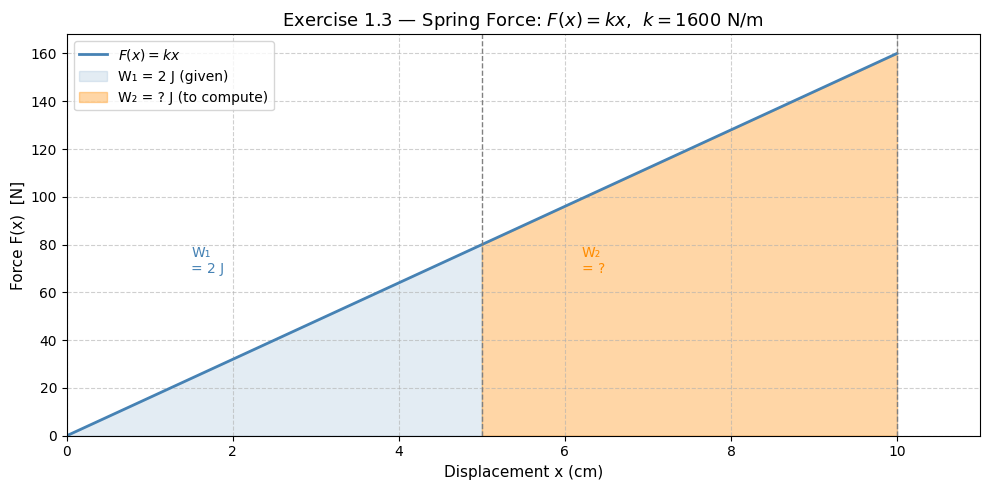

In [4]:
x_full = np.linspace(0, 0.10, 500)
x_shade = np.linspace(a, b, 500)

fig, ax = plt.subplots(figsize=(10, 5))

# Full force curve from 0 to 20 cm stretch
ax.plot(x_full * 100, F(x_full), color='steelblue', linewidth=2, label=r'$F(x) = kx$')

# Shade the area for W1 (0 to 5 cm)
ax.fill_between(np.linspace(0, a, 300) * 100, F(np.linspace(0, a, 300)),
                alpha=0.15, color='steelblue', label='W₁ = 2 J (given)')

# Shade the area for W2 (5 cm to 10 cm) — the region we compute
ax.fill_between(x_shade * 100, F(x_shade),
                alpha=0.35, color='darkorange', label='W₂ = ? J (to compute)')

ax.axvline(x=5,  color='gray',       linestyle='--', linewidth=1)
ax.axvline(x=10, color='gray',       linestyle='--', linewidth=1)
ax.text(1.5, 68, 'W₁\n= 2 J',  fontsize=10, color='steelblue')
ax.text(6.2, 68, 'W₂\n= ?',    fontsize=10, color='darkorange')

ax.set_title(r'Exercise 1.3 — Spring Force: $F(x) = kx$,  $k = 1600$ N/m', fontsize=13)
ax.set_xlabel('Displacement x (cm)', fontsize=11)
ax.set_ylabel('Force F(x)  [N]', fontsize=11)
ax.set_xlim(0, 11)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Trapezoidal Rule

$$W \approx \frac{h}{2}\left[F(x_0) + 2F(x_1) + \cdots + 2F(x_{n-1}) + F(x_n)\right]$$

In [5]:
W_trap = h * (0.5 * f[0] + np.sum(f[1:-1]) + 0.5 * f[-1])
print(f'Work (Trapezoidal Rule) = {W_trap:.6f} J')

Work (Trapezoidal Rule) = 6.000000 J


## 5. Simpson's Rule

$$W \approx \frac{h}{3}\left[F(x_0) + 4F(x_1) + 2F(x_2) + 4F(x_3) + \cdots + F(x_n)\right]$$

In [6]:
coeffs = np.ones(n + 1)
coeffs[1:-1:2] = 4
coeffs[2:-2:2] = 2
W_simp = (h / 3) * np.dot(coeffs, f)
print(f"Work (Simpson's Rule)   = {W_simp:.6f} J")

Work (Simpson's Rule)   = 6.000000 J


## 6. Analytical (Exact) Solution

$$W = \int_{0.05}^{0.10} 1600x\, dx = \left[800x^2\right]_{0.05}^{0.10} = 800(0.01) - 800(0.0025) = 8 - 2 = 6 \text{ J}$$

In [7]:
W_exact = 800 * b**2 - 800 * a**2
print(f'Work (Exact) = 800*b^2 - 800*a^2 = {W_exact:.6f} J  (expected: 6 J)')

Work (Exact) = 800*b^2 - 800*a^2 = 6.000000 J  (expected: 6 J)


## 7. Error Estimation & Results Summary

In [8]:
err_trap = abs(W_exact - W_trap)
err_simp = abs(W_exact - W_simp)
rel_trap = err_trap / W_exact * 100
rel_simp = err_simp / W_exact * 100

print('=' * 58)
print('   Results Summary')
print('=' * 58)
print(f'  Exact (analytical) : {W_exact:>12,.6f} J')
print(f'  Trapezoidal Rule   : {W_trap:>12,.6f} J')
print(f"  Simpson's Rule     : {W_simp:>12,.6f} J")
print('-' * 58)
print(f'  Error (Trap) abs : {err_trap:.4e} J   rel : {rel_trap:.4e} %')
print(f"  Error (Simp) abs : {err_simp:.4e} J   rel : {rel_simp:.4e} %")
print('=' * 58)

   Results Summary
  Exact (analytical) :     6.000000 J
  Trapezoidal Rule   :     6.000000 J
  Simpson's Rule     :     6.000000 J
----------------------------------------------------------
  Error (Trap) abs : 1.7764e-15 J   rel : 2.9606e-14 %
  Error (Simp) abs : 3.5527e-15 J   rel : 5.9212e-14 %


## 8. Error Comparison Plot

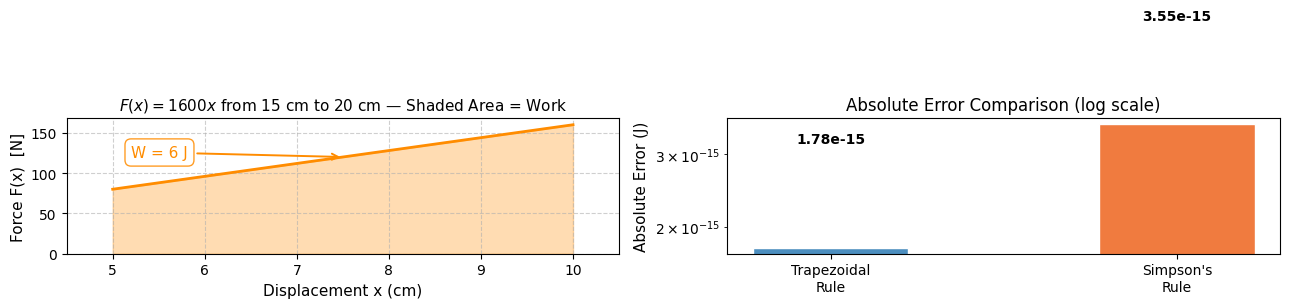

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: force curve with shaded work area
ax1 = axes[0]
ax1.plot(x_shade * 100, F(x_shade), color='darkorange', linewidth=2)
ax1.fill_between(x_shade * 100, F(x_shade), alpha=0.3, color='darkorange')
ax1.set_title(r'$F(x) = 1600x$ from 15 cm to 20 cm — Shaded Area = Work', fontsize=11)
ax1.set_xlabel('Displacement x (cm)', fontsize=11)
ax1.set_ylabel('Force F(x)  [N]', fontsize=11)
ax1.set_xlim(4.5, 10.5)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.annotate(
    f'W = 6 J',
    xy=(7.5, F(0.075)), xytext=(5.2, 120), fontsize=11, color='darkorange',
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='darkorange', alpha=0.85)
)

# Right: error bar chart
ax2 = axes[1]
methods = ['Trapezoidal\nRule', "Simpson's\nRule"]
errors  = [err_trap if err_trap > 0 else 1e-20, err_simp if err_simp > 0 else 1e-20]
colors  = ['#4C8EBF', '#F07B3F']
bars = ax2.bar(methods, errors, color=colors, width=0.45, edgecolor='white')
ax2.set_title('Absolute Error Comparison (log scale)', fontsize=12)
ax2.set_ylabel('Absolute Error (J)', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar, err in zip(bars, [err_trap, err_simp]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.8,
             f'{err:.2e}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()